<a href="https://colab.research.google.com/github/kalaiavk1516-create/python_chats_projects/blob/main/secret_number.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries imported sueecssfully!")

Libraries imported sueecssfully!


In [2]:
#Load the taxis dataset

df = sns.load_dataset('taxis')

print("Dataset loaded sueecssfully!")


Dataset loaded sueecssfully!


In [3]:
df.head()

print("Number of rows and columns:", df.shape)

Number of rows and columns: (6433, 14)


In [4]:
print(df.columns)

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')


In [5]:
# check missing values

missing_values = df.isnull().sum()

print(missing_values)

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [6]:
missing_columns = df.isnull().sum()

missing_columns = missing_columns [missing_columns > 0]

print(missing_columns)

payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [7]:
# separate numberical and categorical columns

numberical_columns = df.select_dtypes(include=[np.number]).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numberical columns:", numberical_columns)

print("Categorical columns:", categorical_columns)

Numberical columns: Index(['passengers', 'distance', 'fare', 'tip', 'tolls', 'total'], dtype='object')
Categorical columns: Index(['color', 'payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough',
       'dropoff_borough'],
      dtype='object')


In [8]:
# fill missing values in numberical columns using median

for column in numberical_columns:
    df[column].fillna(df[column].median())

print("numerical missing values handled.")

numerical missing values handled.


In [9]:
# fill missing values in categorical columns using median

for column in categorical_columns:
    df[column].fillna(df[column].mode()[0])

print("categorical missing values handled.")

categorical missing values handled.


In [12]:
# convert pickup column to datatime

df["pickup"] = pd.to_datetime(df["pickup"], errors="coerce")

print(df["pickup"].dtype)

datetime64[ns]


In [13]:
df = df.dropna(subset=["pickup"])

print("invalid/missing pickup rows removed.")

invalid/missing pickup rows removed.


In [14]:
print("remaining missing values:")

print(df.isnull().sum())

remaining missing values:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


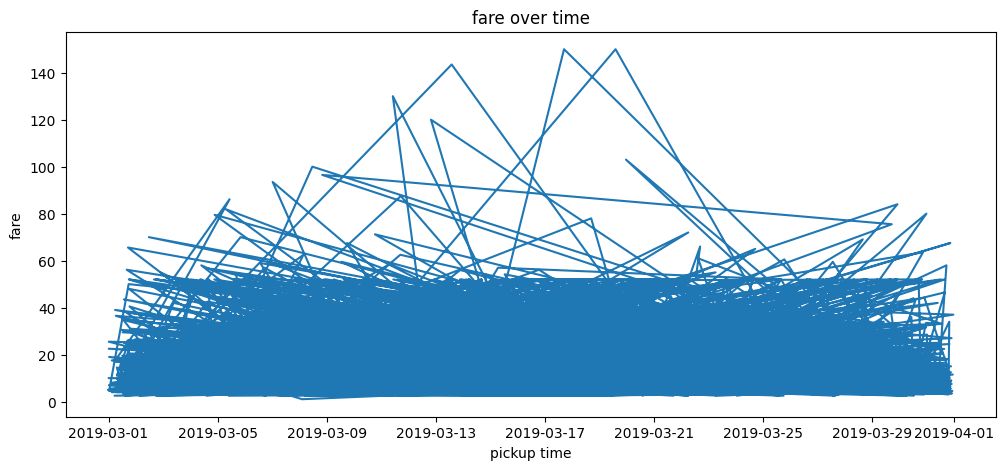

In [15]:
plt.figure(figsize=(12,5))

plt.plot(df["pickup"], df["fare"])

plt.xlabel("pickup time")
plt.ylabel("fare")
plt.title("fare over time")

plt.show()

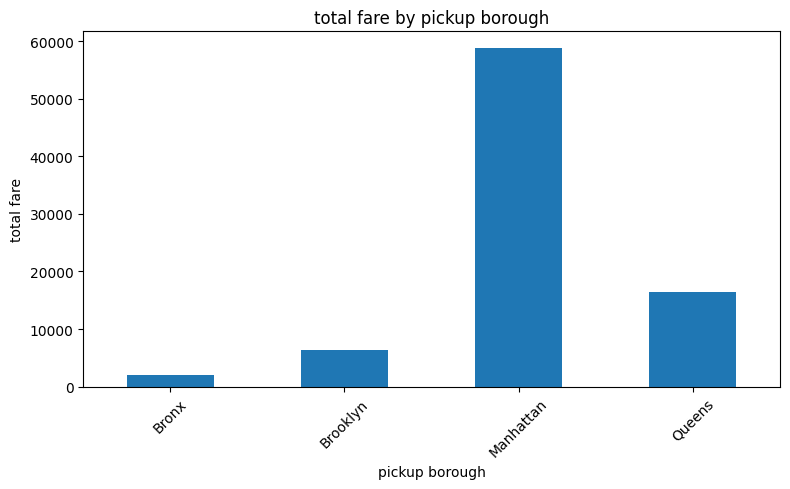

In [16]:
borough_fare = df.groupby("pickup_borough")["fare"].sum()

plt.figure(figsize=(8,5))

borough_fare.plot(kind="bar")

plt.xlabel("pickup borough")
plt.ylabel("total fare")
plt.title("total fare by pickup borough")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


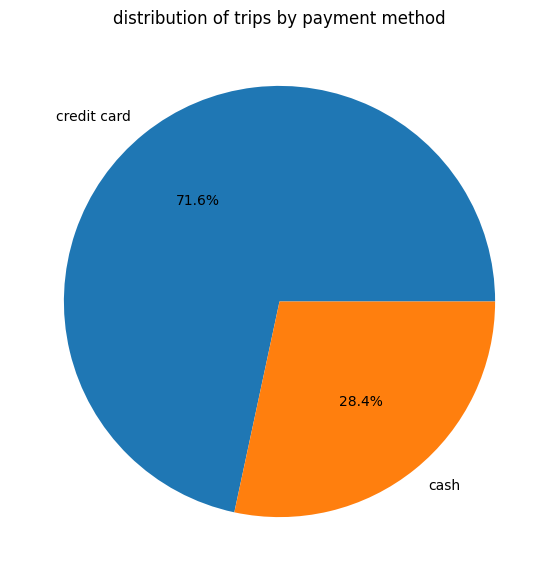

In [17]:
payments_counts = df["payment"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(payments_counts, labels=payments_counts.index, autopct="%1.1f%%")

plt.title("distribution of trips by payment method")

plt.show()

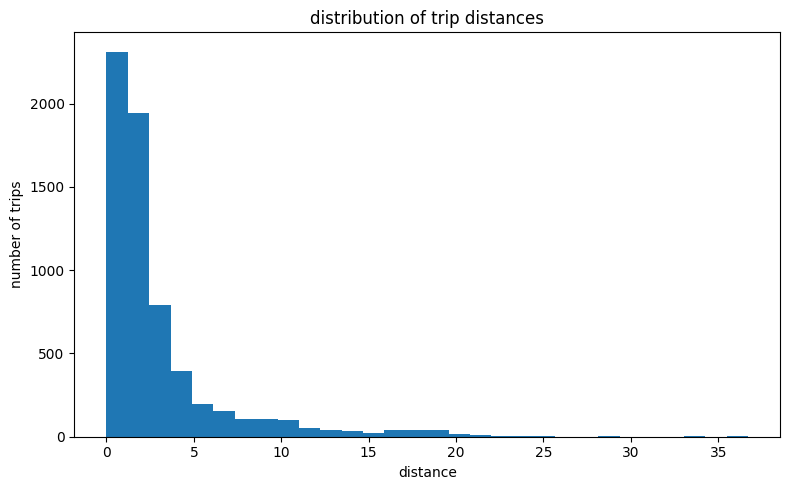

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["distance"],bins=30)

plt.xlabel("distance")
plt.ylabel("number of trips")
plt.title("distribution of trip distances")

plt.tight_layout()

plt.show()

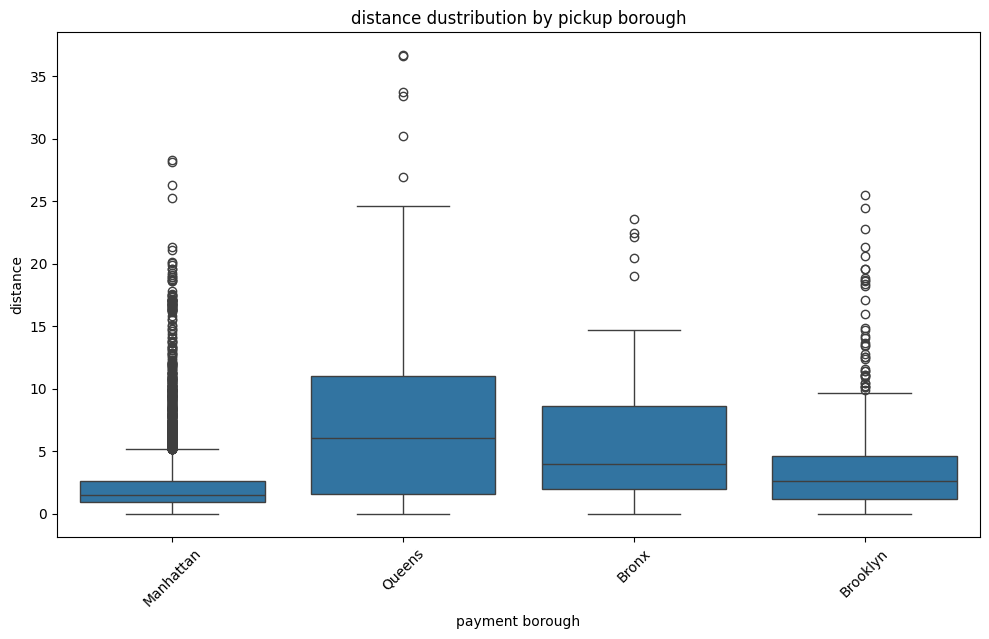

In [28]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="pickup_borough",
    y="distance"
)

plt.xlabel("payment borough")
plt.ylabel("distance")
plt.title("distance dustribution by pickup borough")

plt.tight_layout()
plt.xticks(rotation=45)

plt.show()

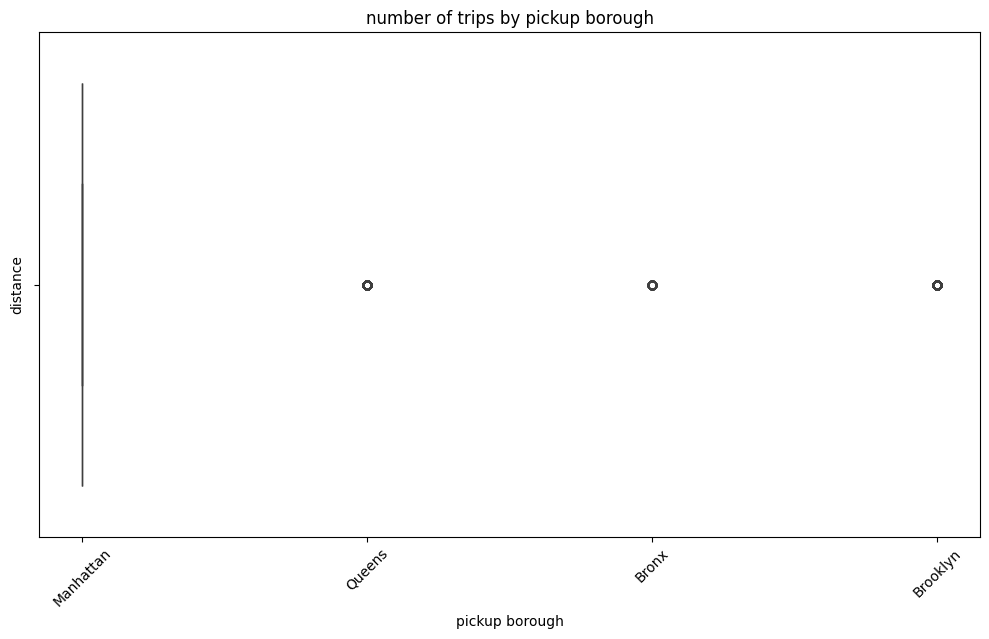

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="pickup_borough"
)

plt.xlabel("pickup borough")
plt.ylabel("distance")
plt.title("number of trips by pickup borough")

plt.tight_layout()
plt.xticks(rotation=45)

plt.show()

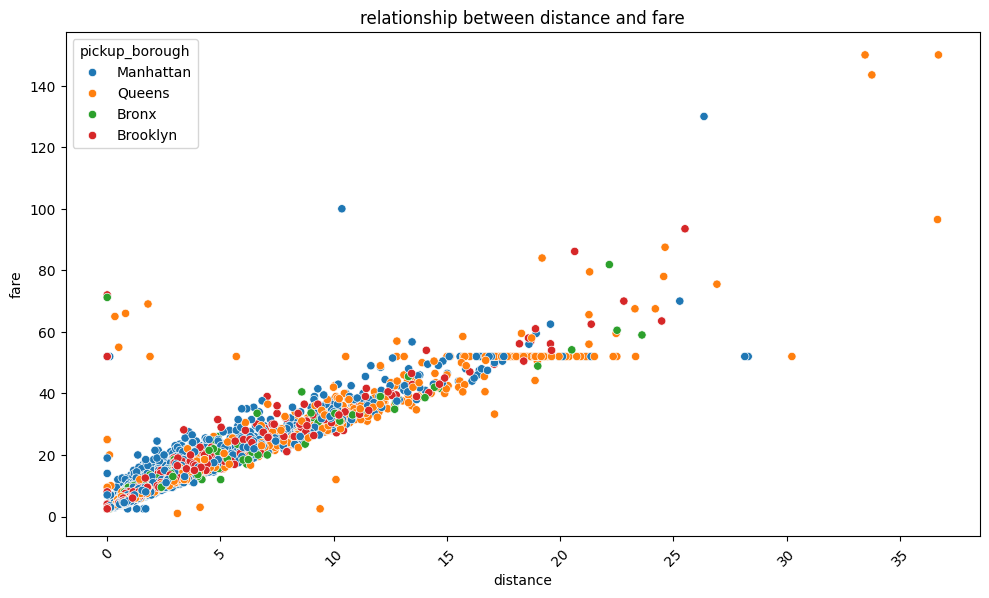

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough"
)

plt.xlabel("distance")
plt.ylabel("fare")
plt.title("relationship between distance and fare")

plt.tight_layout()
plt.xticks(rotation=45)

plt.show()

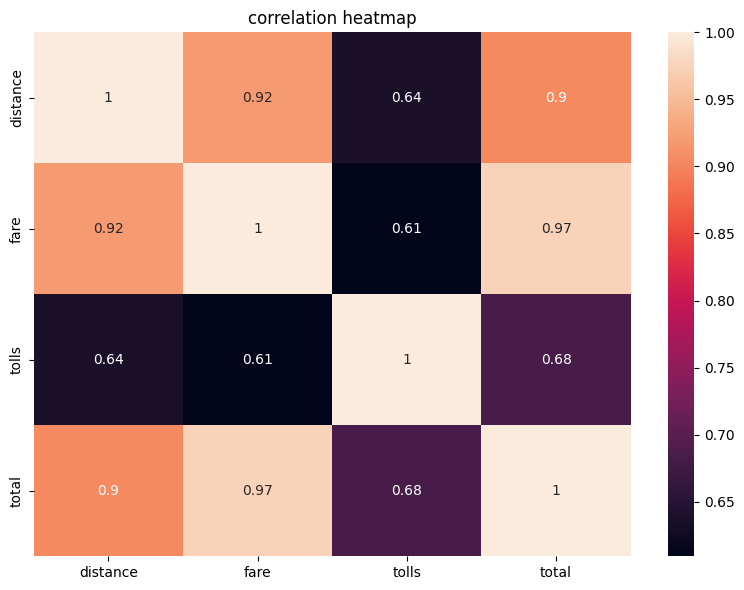

In [35]:
numberical_columns = df[["distance", "fare","tolls","total"]]

correlation_matrix = numberical_columns.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title("correlation heatmap")

plt.tight_layout()

plt.show()

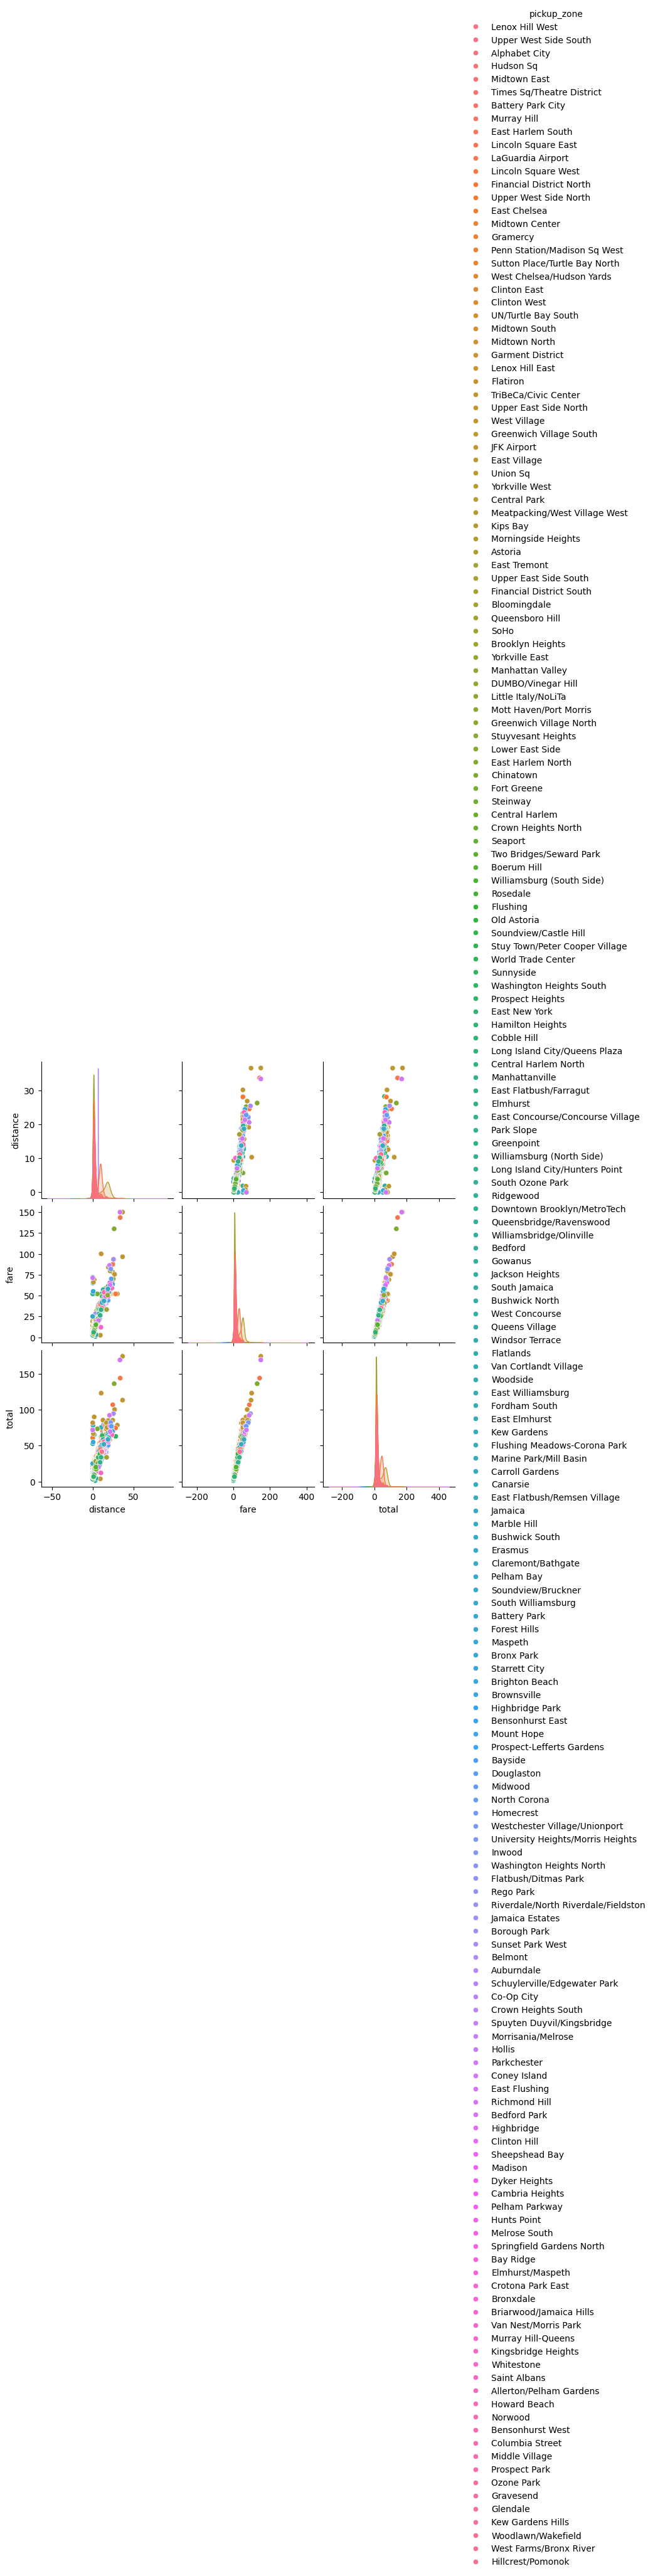

In [36]:
pair_data = df[["distance","fare","total","pickup_zone"]].dropna()

sns.pairplot(
    pair_data,
    vars=["distance","fare","total"],
    hue="pickup_zone"
)

plt.show()

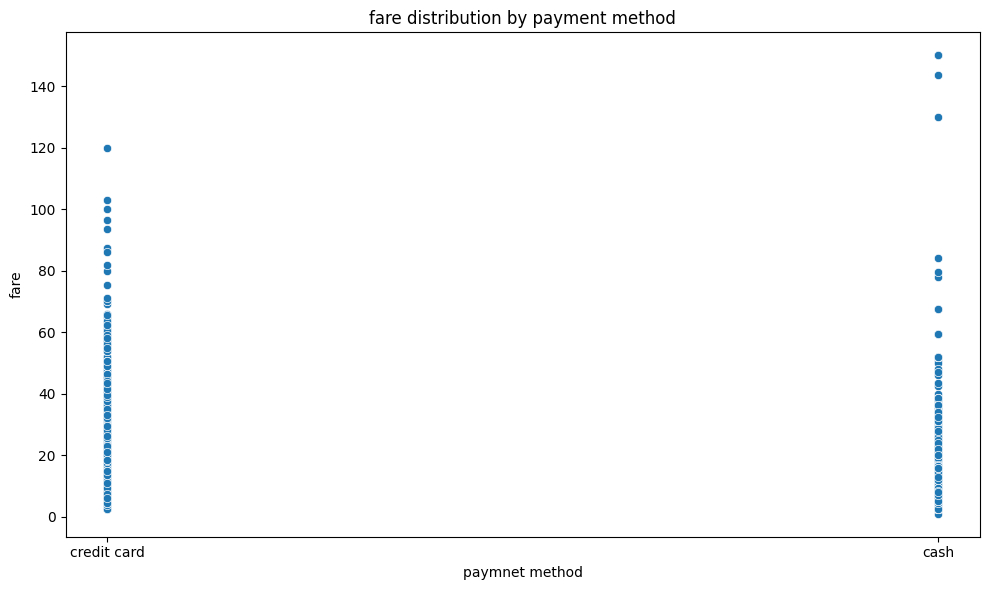

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="payment",
    y="fare")
plt.xlabel("paymnet method")
plt.ylabel("fare")
plt.title("fare distribution by payment method")

plt.tight_layout()

plt.show()